# ru-kws: learning BC-ResNet in Colab


In [1]:
from pathlib import Path
import sys, os, json, subprocess, hashlib, zipfile, tempfile, stat, csv
import torch

REPO_URL = "https://github.com/mole88/ru-kws.git"
REPO_REF = "master"
DATASET_ZIP = Path("/content/drive/MyDrive/russian_commands/russian_commands_v001_clean_manual.zip")

RUN_NAME = "bcresnet_run_002"
RUNS_ROOT = Path("/content/drive/MyDrive/russian_commands/runs")
WINDOW_SECONDS = 3.0
BASE_C = 64                   # 8/12/16/24/48/64; 64 - BC-ResNet-8
BATCH_SIZE = 32
MAX_EPOCHS = 30
LEARNING_RATE = 3e-4
REQUIRE_GPU = torch.cuda.is_available()

RUN_FINAL_TEST = True

RUN_DIR = RUNS_ROOT / RUN_NAME
os.environ["PYTHONUNBUFFERED"] = "1" # for realtime logs output
os.environ["MPLBACKEND"] = "Agg" # for stable working with graphics libs
print("Pun path:", RUN_DIR)


Pun path: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_002


## 1. Connecting Google Drive


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 2. Clone project repo


In [3]:
def run(command, cwd=None):
    print("Run:", " ".join(map(str, command)), flush=True)
    with subprocess.Popen(list(map(str, command)), cwd=cwd,
                          stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                          text=True, encoding="utf-8", errors="replace", bufsize=1) as process:
        for line in process.stdout:
            print(line, end="", flush=True)
        if process.wait():
            raise RuntimeError(f"Error {process.returncode}")

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def extract_cached(archive, parent):
    if not archive.is_file():
        raise FileNotFoundError(f"Fix archive path: {archive}")
    digest = file_sha256(archive)
    target = parent / digest
    marker = target / ".extraction_complete"
    if marker.exists():
        print("Use unziped archive:", target)
        return target, digest
    target.mkdir(parents=True, exist_ok=True)
    root = target.resolve()
    with zipfile.ZipFile(archive) as zf:
        members = zf.infolist()
        for member in members:
            destination = (root / member.filename).resolve()
            if not destination.is_relative_to(root) or stat.S_ISLNK(member.external_attr >> 16):
                raise ValueError(f"Wrong path: {member.filename}")
        print(f"Unpacking {len(members)} files...", flush=True)
        zf.extractall(target)
    marker.write_text(digest)
    return target, digest

def find_root(parent, marker, required):
    candidates = [p.parent for p in parent.rglob(marker)
                  if "__MACOSX" not in p.parts and all((p.parent / item).exists() for item in required)]
    if len(candidates) != 1:
        raise ValueError(f"Ожидалась одна папка с {marker}, найдены: {candidates}")
    return candidates[0]

REPO = Path(tempfile.mkdtemp(prefix="ru-kws-", dir="/content"))
run(["git", "clone", "--filter=blob:none", "--no-checkout", REPO_URL, REPO])
run(["git", "fetch", "--depth", "1", "origin", REPO_REF], cwd=REPO)
run(["git", "checkout", "--detach", "FETCH_HEAD"], cwd=REPO)
revision = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO, text=True).strip()
source_info = {"mode": "github", "url": REPO_URL, "requested_ref": REPO_REF, "revision": revision}
print("Project:", REPO)
print(json.dumps(source_info, ensure_ascii=False, indent=2))


Run: git clone --filter=blob:none --no-checkout https://github.com/mole88/ru-kws.git /content/ru-kws-8cqnwmiw
Cloning into '/content/ru-kws-8cqnwmiw'...
Run: git fetch --depth 1 origin master
From https://github.com/mole88/ru-kws
 * branch            master     -> FETCH_HEAD
Run: git checkout --detach FETCH_HEAD
HEAD is now at 87b28ed Skip commands longer than the configured window in all splits
Project: /content/ru-kws-8cqnwmiw
{
  "mode": "github",
  "url": "https://github.com/mole88/ru-kws.git",
  "requested_ref": "master",
  "revision": "87b28eda21f1fa3a0f9a6aa7382b4f4416d26ca1"
}


## 3. Установка и проверка среды

Используем PyTorch/torchaudio среды Colab; эта ячейка не переустанавливает их.
Чтение WAV реализовано через SoundFile и не требует `torchcodec`.
Если проверка GPU не проходит, включите GPU и перезапустите среду.


In [4]:
run([sys.executable, "-m", "pip", "install", "numpy>=1.24", "soundfile>=0.12", "PyYAML>=6", "matplotlib>=3.6", "packaging"])
run([sys.executable, "-m", "pip", "install", "--no-deps", "-e", REPO])
probe = """
import sys, json, torch, torchaudio
from packaging.version import Version
from ru_kws.audio.frontend import LogMelFrontend
from ru_kws.models.bcresnet import BCResNets
assert Version(torch.__version__.split('+')[0]) >= Version('2.5')
assert Version(torchaudio.__version__.split('+')[0]) >= Version('2.5')
assert not REQUIRE_GPU or torch.cuda.is_available(), 'Включите GPU в настройках Colab'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
with torch.inference_mode():
    x = LogMelFrontend().to(device)(torch.zeros(1, 48000, device=device))
    model = BCResNets(8, num_classes=8).to(device).eval()
    y = model(x)
assert x.shape == (1, 1, 40, 301) and y.shape == (1, 8)
print(json.dumps({'python': sys.version, 'torch': str(torch.__version__),
    'torchaudio': str(torchaudio.__version__), 'device': device,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None}, indent=2))
"""
run([sys.executable, "-c", "REQUIRE_GPU = " + repr(REQUIRE_GPU) + "\n" + probe])


Run: /usr/bin/python3 -m pip install numpy>=1.24 soundfile>=0.12 PyYAML>=6 matplotlib>=3.6 packaging
Run: /usr/bin/python3 -m pip install --no-deps -e /content/ru-kws-8cqnwmiw
Obtaining file:///content/ru-kws-8cqnwmiw
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for ru-kws (pyproject.toml): started
  Building editable for ru-kws (pyproject.toml): finished with status 'done'
  Created wheel for ru-kws: filename=ru_kws-0.1.0-0.editable-py3-none-any.whl size=1300 sha256=ebda1a305b743719a6771d8e22f9a572afbeaade4cbefa9fd502b604b

## 4. Локальная копия датасета

Корень с `labels.json` находится автоматически, включая вложенную папку архива.
Повторная распаковка того же архива в одной среде пропускается.


In [5]:
unpacked, dataset_archive_hash = extract_cached(DATASET_ZIP, Path("/content/ru_kws_data"))
DATA_ROOT = find_root(unpacked, "labels.json", ["splits/train.jsonl", "splits/val.jsonl", "splits/test.jsonl"])
print("Датасет:", DATA_ROOT)
print("Метки:", json.loads((DATA_ROOT / "labels.json").read_text(encoding="utf-8")))


Unpacking 11316 files...
Датасет: /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual
Метки: {'next': 0, 'back': 1, 'repeat': 2, 'start_timer': 3, 'stop_timer': 4, 'time_left': 5, 'unknown': 6, 'background': 7}


## 5. Configuration and validation data



In [6]:
import yaml
config = yaml.safe_load((REPO / "configs/baseline.yaml").read_text(encoding="utf-8"))
config["audio"]["window_seconds"] = WINDOW_SECONDS
config["model"]["base_c"] = BASE_C
config["training"].update(batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
                          learning_rate=LEARNING_RATE, num_workers=0)
CONFIG_PATH = Path("/content/ru_kws_colab_config.yaml")
CONFIG_PATH.write_text(yaml.safe_dump(config, sort_keys=False), encoding="utf-8")
print(CONFIG_PATH.read_text())
run([sys.executable, "-m", "ru_kws.data.validate", "--data-root", DATA_ROOT,
     "--window-seconds", WINDOW_SECONDS], cwd=REPO)


seed: 42
audio:
  sample_rate: 16000
  window_seconds: 3.0
frontend:
  n_fft: 512
  win_length: 480
  hop_length: 160
  n_mels: 40
  power: 2.0
  center: true
  log_eps: 1.0e-06
model:
  name: bcresnet
  base_c: 64
training:
  batch_size: 32
  num_workers: 0
  max_epochs: 30
  learning_rate: 0.0003
  label_smoothing: 0.1
  early_stopping_patience: 8
  scheduler_patience: 2

Run: /usr/bin/python3 -m ru_kws.data.validate --data-root /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual --window-seconds 3.0
train: kept 6959, dropped 28 commands longer than 3.0s; by label: {'back': 7, 'time_left': 3, 'repeat': 2, 'start_timer': 8, 'stop_timer': 6, 'next': 2}
val: kept 1483, dropped 10 commands longer than 3.0s; by label: {'start_timer': 1, 'repeat': 1, 'stop_timer': 7, 'back': 1}
test: kept 1496, dropped 4 commands longer than 3.0s; by label: {'back': 1, 'start_timer': 2, 'repeat': 1}
train {'background': 700, 'next': 697, 

## 6. Learning


In [7]:
if RUN_DIR.exists() and any(RUN_DIR.iterdir()):
    raise FileExistsError(f"Run already exist: {RUN_DIR}.")
run([sys.executable, "-m", "ru_kws.train", "--config", CONFIG_PATH,
     "--data-root", DATA_ROOT, "--run-dir", RUN_DIR, "--device", "auto"], cwd=REPO)
(RUN_DIR / "colab_source.json").write_text(json.dumps({
    "source": source_info, "dataset_archive": str(DATASET_ZIP),
    "dataset_archive_sha256": dataset_archive_hash,
}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Best checkpoint:", RUN_DIR / "best.pt")


FileExistsError: Run already exist: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_002.

## 7. Графики обучения
Строятся из сохранённого `history.csv`, без повторного обучения.


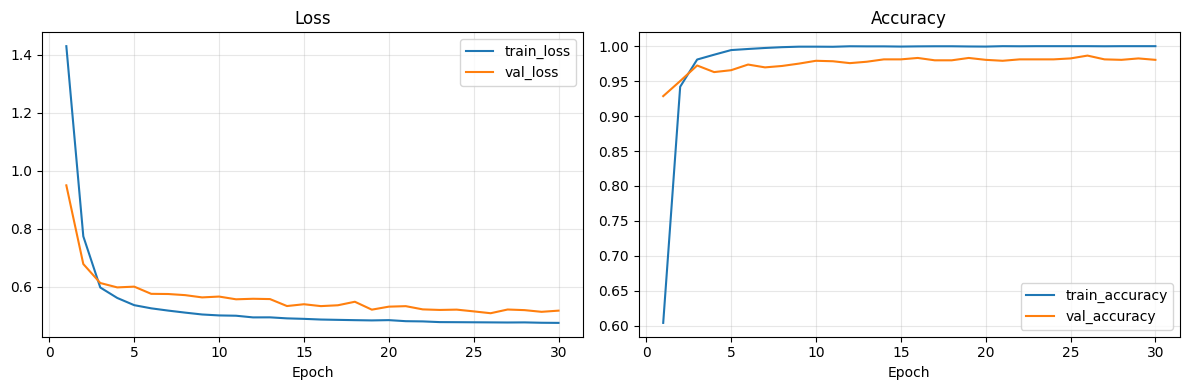

In [22]:
import matplotlib.pyplot as plt
with (RUN_DIR / "history.csv").open(encoding="utf-8") as stream:
    history = list(csv.DictReader(stream))
epochs = [int(row["epoch"]) for row in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for key in ("train_loss", "val_loss"):
    axes[0].plot(epochs, [float(row[key]) for row in history], label=key)
for key in ("train_accuracy", "val_accuracy"):
    axes[1].plot(epochs, [float(row[key]) for row in history], label=key)
for ax, title in zip(axes, ("Loss", "Accuracy")):
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
(RUN_DIR / "reports").mkdir(exist_ok=True)
fig.savefig(RUN_DIR / "reports" / "training.png", dpi=150)
plt.show()


## 8. Оценка лучшего checkpoint на validation

CLI сам загружает `best.pt`, его frontend config и label map.
Это classification-метрики клипов, не FP/hour и не задержка потокового распознавания.


Запуск: /usr/bin/python3 -m ru_kws.evaluate --checkpoint /content/drive/MyDrive/russian_commands/runs/bcresnet_run_002/best.pt --data-root /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual --split val --output /content/drive/MyDrive/russian_commands/runs/bcresnet_run_002/reports/val.json
val: kept 1483, dropped 10 commands longer than 3.0s; by label: {'start_timer': 1, 'repeat': 1, 'stop_timer': 7, 'back': 1}
{
  "count": 1483,
  "accuracy": 0.9865138233310856,
  "macro_f1": 0.9890681013708458,
  "per_class": {
    "next": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 150
    },
    "back": {
      "precision": 1.0,
      "recall": 0.993006993006993,
      "f1": 0.9964912280701755,
      "support": 143
    },
    "repeat": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 149
    },
    "start_timer": {
      "precision": 0.9030303030303031,
      "re

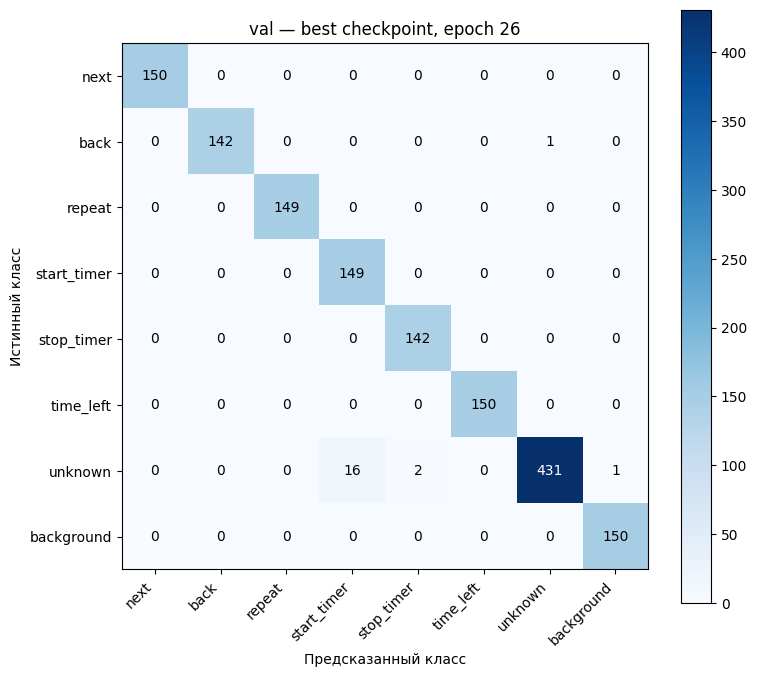

In [23]:
def evaluate_split(split):
    checkpoint = RUN_DIR / "best.pt"
    if not checkpoint.is_file():
        raise FileNotFoundError(f"Не найден checkpoint: {checkpoint}")
    output_path = RUN_DIR / "reports" / f"{split}.json"
    run([sys.executable, "-m", "ru_kws.evaluate", "--checkpoint", checkpoint,
         "--data-root", DATA_ROOT, "--split", split, "--output", output_path], cwd=REPO)
    return json.loads(output_path.read_text(encoding="utf-8"))

def show_report(report):
    import numpy as np
    print(f"Epoch: {report['epoch']} | split: {report['split']} | N={report['count']}")
    print(f"Accuracy: {report['accuracy']:.4f} | macro F1: {report['macro_f1']:.4f}")
    print(f"{'Class':20s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>8s}")
    for name in report["class_order"]:
        row = report["per_class"][name]
        print(f"{name:20s} {row['precision']:10.4f} {row['recall']:10.4f} {row['f1']:10.4f} {row['support']:8d}")
    cm = np.array(report["confusion_matrix"])
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    names = report["class_order"]
    ax.set_xticks(range(len(names)), names, rotation=45, ha="right")
    ax.set_yticks(range(len(names)), names)
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha="center", va="center",
                color="white" if value > cm.max() / 2 else "black")
    ax.set_xlabel("Предсказанный класс"); ax.set_ylabel("Истинный класс")
    ax.set_title(f"{report['split']} — best checkpoint, epoch {report['epoch']}")
    fig.colorbar(im, ax=ax); fig.tight_layout()
    fig.savefig(RUN_DIR / "reports" / f"{report['split']}_confusion.png", dpi=150)
    plt.show()

val_report = evaluate_split("val")
show_report(val_report)


## 9. Финальный test — опционально

После фиксации модели и настроек поставьте `RUN_FINAL_TEST=True` в настройках
или непосредственно перед условием ниже. По умолчанию при «Выполнить все» test не запускается.


Запуск: /usr/bin/python3 -m ru_kws.evaluate --checkpoint /content/drive/MyDrive/russian_commands/runs/bcresnet_run_002/best.pt --data-root /content/ru_kws_data/8213961888b37d67ceb000ca6ffdf9f5bfe330d6f68003fcd54e49f002005884/russian_commands_v001_clean_manual --split test --output /content/drive/MyDrive/russian_commands/runs/bcresnet_run_002/reports/test.json
test: kept 1496, dropped 4 commands longer than 3.0s; by label: {'back': 1, 'start_timer': 2, 'repeat': 1}
{
  "count": 1496,
  "accuracy": 0.9618983957219251,
  "macro_f1": 0.9689478425001476,
  "per_class": {
    "next": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 150
    },
    "back": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 149
    },
    "repeat": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0,
      "support": 149
    },
    "start_timer": {
      "precision": 0.9856115107913669,
      "recall": 0.9256756756756757,
      "f1": 0.954

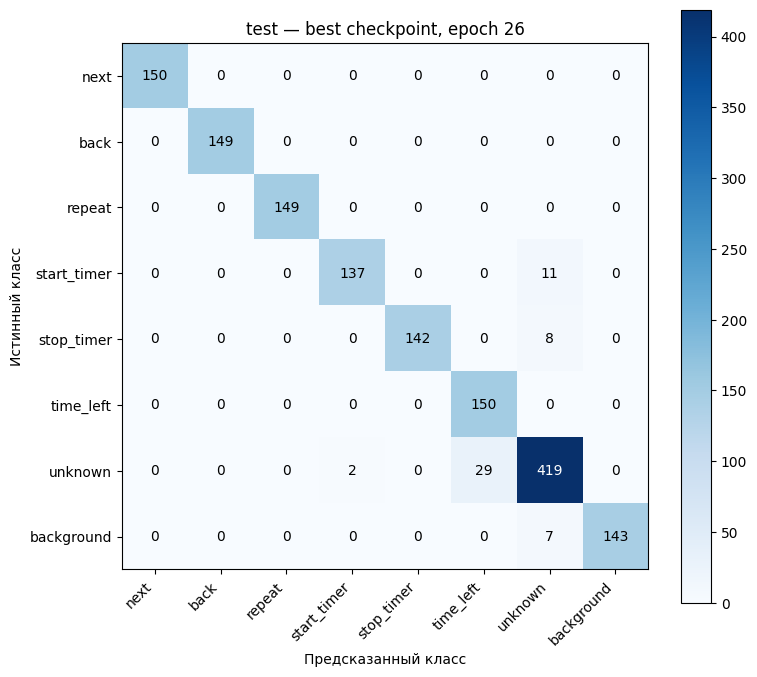

Все результаты на Drive: /content/drive/MyDrive/russian_commands/runs/bcresnet_run_002


In [26]:
if RUN_FINAL_TEST:
    test_report = evaluate_split("test")
    show_report(test_report)
else:
    print("Test пропущен.")
print("Все результаты на Drive:", RUN_DIR)
